## Dataset selector

In [34]:
import ipywidgets as widgets
from IPython.display import display as ipy_display

# ── Dataset selector ───────────────────────────
dataset_selector = widgets.Dropdown(
    options={
        "eff_rank_best":   "../data/movielens/ncols_10/eff_rank_best",
        "eff_rank_middle": "../data/movielens/ncols_10/eff_rank_middle",
        "eff_rank_worst":  "../data/movielens/ncols_10/eff_rank_worst",
    },
    value="../data/movielens/ncols_10/eff_rank_best",
    description="Dataset:",
)
ipy_display(dataset_selector)

Dropdown(description='Dataset:', options={'eff_rank_best': '../data/movielens/ncols_10/eff_rank_best', 'eff_ra…

## Outlier Target Selection (MIA Paper §4.3)

Selection criterion from the paper:

> *"records that either have rare categorical attribute values or numerical values outside the attribute's 95% quantile"*

**Adaptation for MovieLens:**
All columns are Ordinal (0-10 integers). Since the value space is discrete and small,
we use **frequency-based rarity scoring only** (no p95 threshold).

**Selection pipeline:**

1. **Rarity scoring** — Flag records with rare values (frequency < 1%); score by inverse frequency
2. **Score matrix** — Normalize scores to [0, 1] and combine
3. **Top-N selection** — Pick the top-scoring records by total normalized score

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ─────────────────────────────────
RARE_THRESHOLD  = 0.01   # frequency threshold for rare values
N_TARGETS       = 5      # number of outlier records to select

# ── Data loading ───────────────────────────────
# Assign sequential IDs compatible with SDR's load_local_data_as_df
DATA_DIR = dataset_selector.value
df_raw = pd.read_csv(f"{DATA_DIR}.csv")
df_raw["ID"] = [f"ID{i}" for i in range(len(df_raw))]
df = df_raw.set_index("ID")

feat_cols = df.columns.tolist()

print(f"Dataset: {DATA_DIR}")
print(f"Shape: {df.shape}")
print(f"Feature columns ({len(feat_cols)}): {feat_cols}")

Dataset: ../data/movielens/ncols_10/eff_rank_worst
Shape: (200948, 10)
Feature columns (10): ['Action', 'Adventure', 'Comedy', 'Crime', 'Drama', 'Fantasy', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller']


### Step 1 — Rarity scoring

- **Criterion**: value frequency < `RARE_THRESHOLD` (default 1%)
- **Score**: `1 / frequency`  (rarer values score higher)

In [49]:
cat_scores = pd.DataFrame(0.0, index=df.index, columns=feat_cols)
cat_rare_vals = {}

for col in feat_cols:
    freq = df[col].value_counts(normalize=True)
    rare_vals = freq[freq < RARE_THRESHOLD]
    cat_rare_vals[col] = rare_vals
    freq_series = df[col].map(freq.to_dict()).astype(float)
    cat_scores[col] = np.where(
        freq_series < RARE_THRESHOLD,
        1.0 / freq_series.clip(lower=1e-10),
        0.0,
    )

# Summary table of rare values
rare_summary_rows = []
for col, rare_vals in cat_rare_vals.items():
    for val, freq in rare_vals.items():
        rare_summary_rows.append({
            "column": col, "rare value": val,
            "frequency (%)": round(freq * 100, 3),
            "# records": round(freq * len(df)),
            "score": round(1.0 / freq, 1),
        })

rare_df = (
    pd.DataFrame(rare_summary_rows, columns=["column", "rare value", "frequency (%)", "# records", "score"])
    .sort_values("frequency (%)")
    .reset_index(drop=True)
)
display(rare_df)

,column,rare value,frequency (%),# records,score
0,Drama,0,0.017,34,5910.2
1,Comedy,0,0.127,255,788.0
2,Drama,3,0.189,379,530.2
3,Action,0,0.368,740,271.6
4,Thriller,0,0.388,780,257.6
5,Crime,3,0.446,897,224.0
6,Comedy,3,0.473,950,211.5
7,Adventure,0,0.488,980,205.0
8,Thriller,3,0.488,980,205.0
9,Action,3,0.577,1160,173.2


### Step 2 — Score normalization

Normalize each column's scores to [0, 1] and combine into a single matrix.
Records with at least one non-zero score are **outlier candidates**.

In [50]:
scores_raw = cat_scores[feat_cols]

# Normalize each column to [0, 1] by dividing by its maximum score
col_max = scores_raw.max()
scores_norm = scores_raw.div(col_max.where(col_max > 0, 1.0))

# Tiebreaker: add a tiny fraction of the raw score so that when two records
# share the same normalized score, the one with higher raw rarity wins
global_max = scores_raw.max().max()
scores = scores_norm + scores_raw * (1e-6 / global_max) if global_max > 0 else scores_norm

is_candidate = scores.gt(0).any(axis=1)
candidates = scores[is_candidate].copy()
candidates["total score"] = candidates[feat_cols].sum(axis=1)

print(f"Outlier candidates: {is_candidate.sum()} / {len(df)} records")

# Top 15 candidates (display with [0,1] normalized scores)
display(
    scores_norm[is_candidate]
    .assign(**{"total score": candidates["total score"]})
    .sort_values("total score", ascending=False)
    .head(15)
    .round(3)
    .style.background_gradient(cmap="YlOrRd", axis=0, subset=feat_cols)
)

Outlier candidates: 14005 / 200948 records


,Action,Adventure,Comedy,Crime,Drama,Fantasy,Mystery,Romance,Sci-Fi,Thriller,total score
ID,,,,,,,,,,,
ID29505,0.638000,0.830000,0.268000,1.000000,0.090000,1.000000,1.000000,1.000000,1.000000,0.796000,7.622000
ID25644,0.638000,0.830000,0.268000,1.000000,0.021000,1.000000,1.000000,1.000000,1.000000,0.796000,7.553000
ID50839,0.638000,0.830000,0.000000,1.000000,0.090000,1.000000,1.000000,1.000000,1.000000,0.796000,7.353000
ID38905,0.638000,0.000000,0.268000,1.000000,0.090000,1.000000,1.000000,1.000000,1.000000,0.796000,6.792000
ID158954,0.638000,0.000000,0.268000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.796000,6.702000
ID179997,0.638000,0.830000,0.268000,0.000000,0.090000,1.000000,1.000000,1.000000,1.000000,0.796000,6.622000
ID64709,0.638000,0.830000,0.268000,0.000000,0.021000,1.000000,1.000000,1.000000,1.000000,0.796000,6.553000
ID64353,0.638000,0.830000,0.000000,1.000000,0.019000,1.000000,1.000000,0.000000,1.000000,0.796000,6.283000
ID115800,0.638000,0.830000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.796000,6.264000


### Distribution of outlier scores

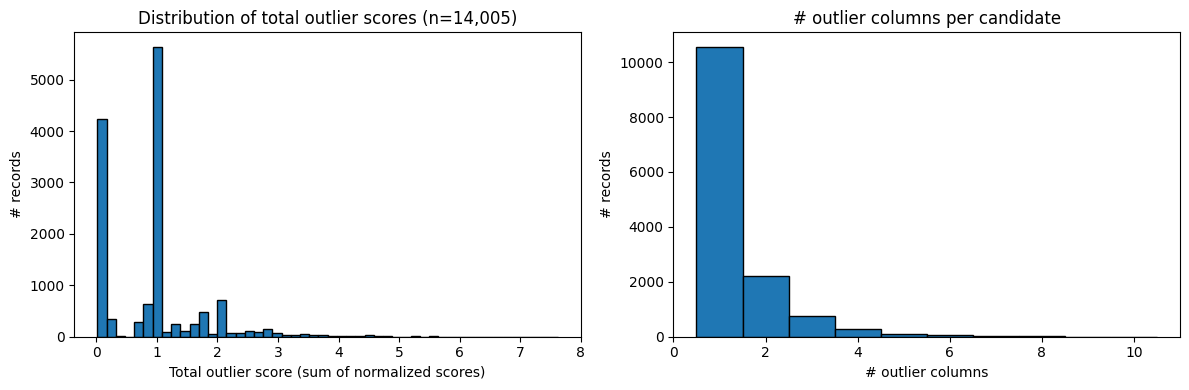

In [51]:
# Distribution of outlier scores (candidates only)
cand_scores = scores_norm[is_candidate].copy()
cand_total = cand_scores[feat_cols].sum(axis=1)
cand_n_cols = cand_scores[feat_cols].gt(0).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cand_total, bins=50, edgecolor="black")
axes[0].set_xlabel("Total outlier score (sum of normalized scores)")
axes[0].set_ylabel("# records")
axes[0].set_title(f"Distribution of total outlier scores (n={len(cand_total):,})")

axes[1].hist(cand_n_cols, bins=range(1, cand_n_cols.max() + 2), edgecolor="black", align="left")
axes[1].set_xlabel("# outlier columns")
axes[1].set_ylabel("# records")
axes[1].set_title("# outlier columns per candidate")

plt.tight_layout()
plt.show()

### Step 3 — Final selection: top N records

Select the top `N_TARGETS` records by total normalized score.
Ties are broken by number of outlier columns (more = higher priority).

In [52]:
candidates_sorted = candidates.copy()
candidates_sorted["n_outlier_cols"] = candidates_sorted[feat_cols].gt(0).sum(axis=1)
candidates_sorted = candidates_sorted.sort_values(
    ["total score", "n_outlier_cols"], ascending=[False, False]
)

selected_ids = candidates_sorted.index[:N_TARGETS].tolist()
result_rows = []

for sid in selected_ids:
    rec = scores.loc[sid]
    outlier_cols = rec[rec > 0].index.tolist()
    primary_col = rec.idxmax()
    result_rows.append({
        "selected ID":     sid,
        "primary column":  primary_col,
        "value":           df.loc[sid, primary_col],
        "norm. score":     round(rec[primary_col], 3),
        "outlier columns": ", ".join(outlier_cols),
    })

result_df = pd.DataFrame(result_rows).set_index("selected ID")
display(result_df)

print("\nSelected IDs:", str(selected_ids).replace("'", '"'))

,primary column,value,norm. score,outlier columns
selected ID,,,,
ID29505,Crime,3,1.0,"Action, Adventure, Comedy, Crime, Drama, Fanta..."
ID25644,Crime,3,1.0,"Action, Adventure, Comedy, Crime, Drama, Fanta..."
ID50839,Crime,3,1.0,"Action, Adventure, Crime, Drama, Fantasy, Myst..."
ID38905,Crime,3,1.0,"Action, Comedy, Crime, Drama, Fantasy, Mystery..."
ID158954,Crime,3,1.0,"Action, Comedy, Crime, Fantasy, Mystery, Roman..."



Selected IDs: ["ID29505", "ID25644", "ID50839", "ID38905", "ID158954"]


In [53]:
# Inspect the raw data of selected records
display(df.loc[selected_ids])

,Action,Adventure,Comedy,Crime,Drama,Fantasy,Mystery,Romance,Sci-Fi,Thriller
ID,,,,,,,,,,
ID29505,3,3,3,3,3,3,3,3,3,3
ID25644,3,3,3,3,2,3,3,3,3,3
ID50839,3,3,1,3,3,3,3,3,3,3
ID38905,3,4,3,3,3,3,3,3,3,3
ID158954,3,1,3,3,6,3,3,3,3,3


# Distribution of each column

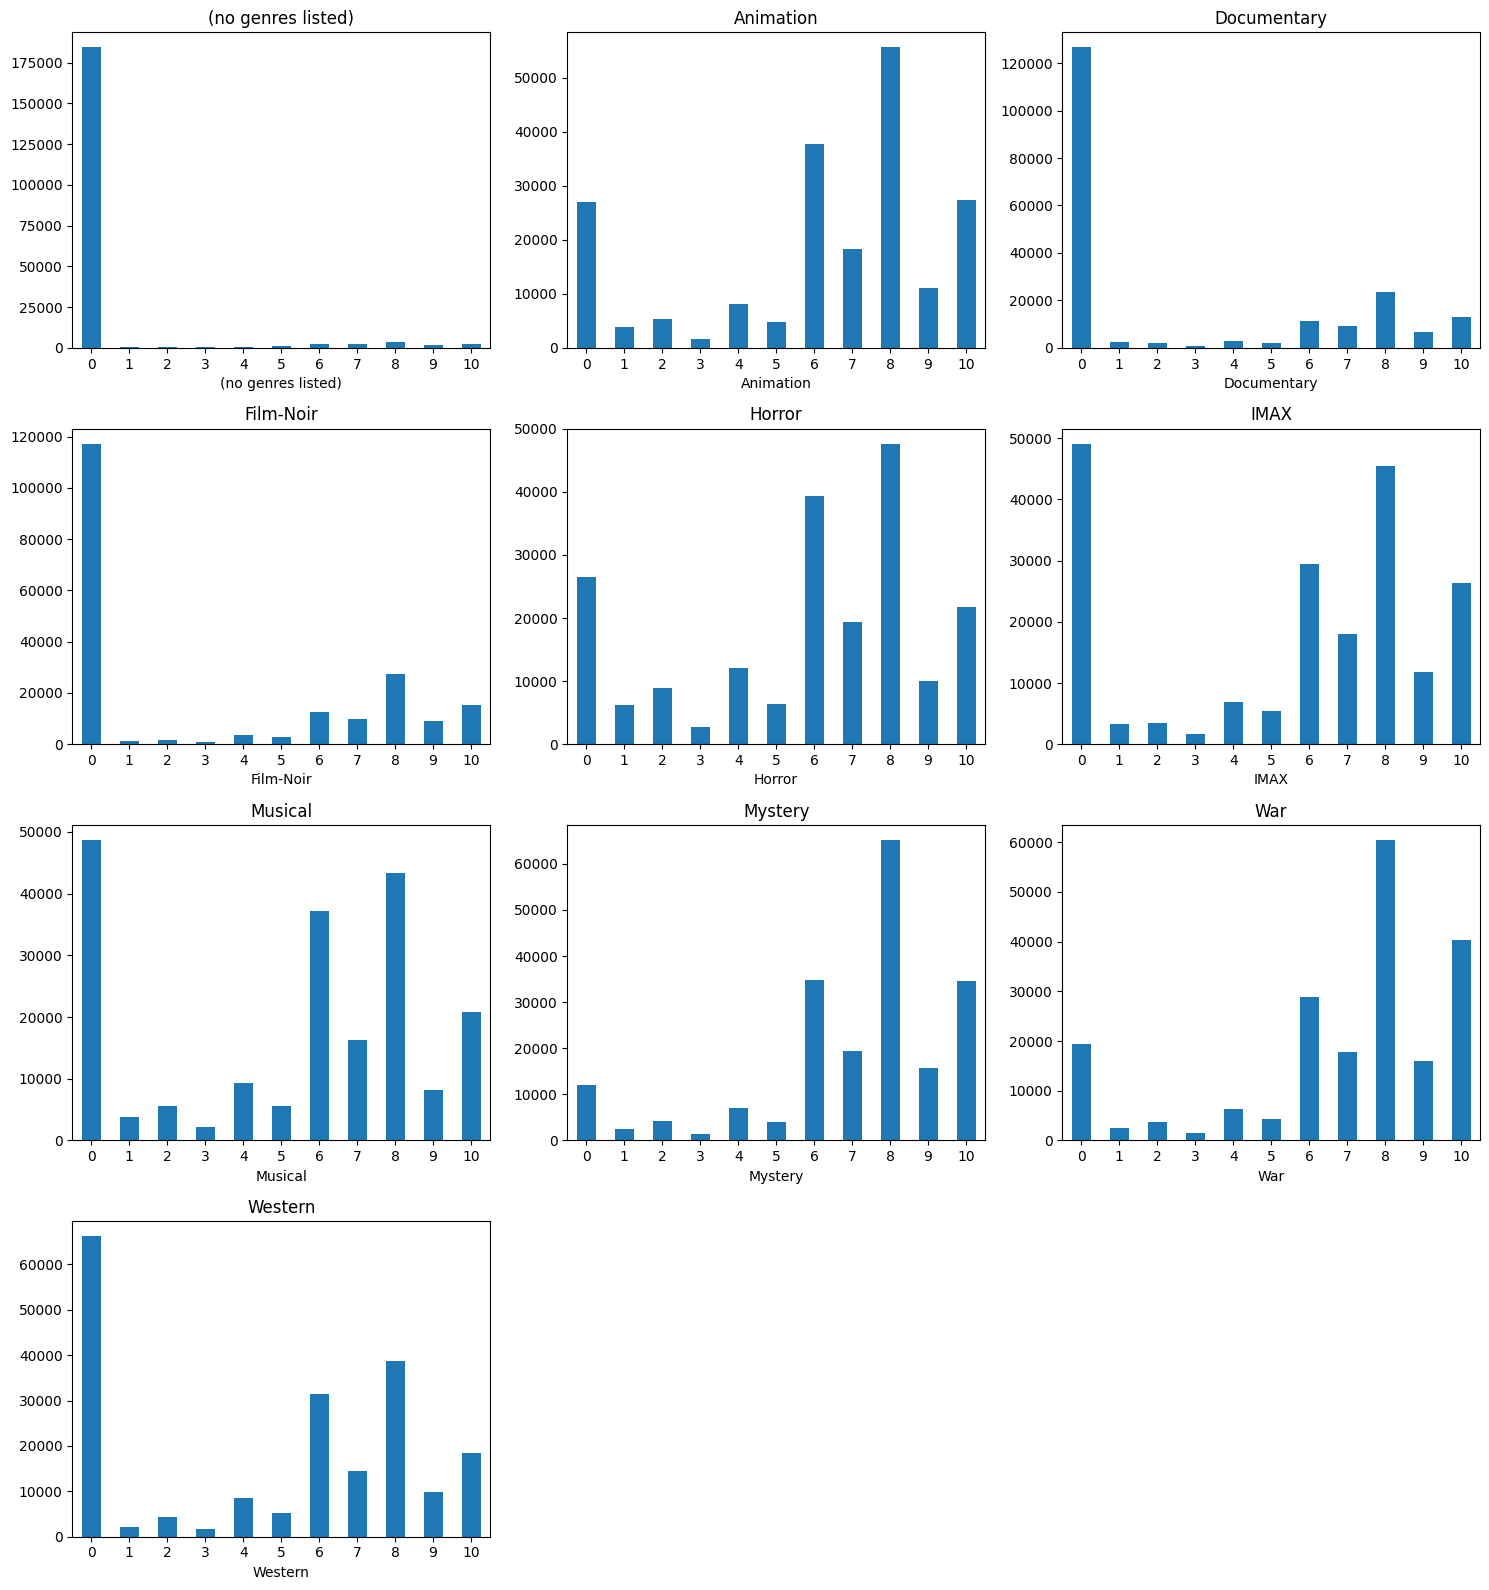

In [41]:
df = pd.read_csv("../data/movielens/ncols_10/eff_rank_best.csv")
feat_cols = df.columns.tolist()


# ── Distribution of each column ────────────────
n = len(feat_cols)

fig, axes = plt.subplots(
    nrows=(n + 2) // 3,
    ncols=3,
    figsize=(15, 4 * ((n + 2) // 3))
)
axes = axes.flatten()

# All columns are Ordinal (0-10) → bar chart
for ax, col in zip(axes, feat_cols):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=0)

# Hide unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()